In [5]:
import heapq
import matplotlib.pyplot as plt

grid = [
    [0, 0, 0, 0, 0],
    [0, 1, 1, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 1, 0, 1, 0],
    [0, 0, 0, 0, 0]
]

start = (0 , 0)
goal = (4 , 4)

def heuristic(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


def astar(grid, start, goal):
    rows = len(grid)
    cols = len(grid[0])

    open_list = []
    heapq.heappush(open_list, (0, start))

    came_from = {}

    g_score = {start: 0}

    f_score = {
        start: heuristic(start, goal)
    }

    direction = [
        (-1, 0),  # Up
        (1, 0),   # Down
        (0, -1),  # Left
        (0, 1)    # Right
    ]

    while open_list:

        current_f, current = heapq.heappop(open_list)

        
        if current == goal:
            path = []

            while current in came_from:
                path.append(current)
                current = came_from[current]

            path.append(start)
            path.reverse()

            return path

        r, c = current

        for dr, dc in direction:

            nr = r + dr
            nc = c + dc

        
            if (
                0 <= nr < rows
                and 0 <= nc < cols
                and grid[nr][nc] == 0
            ):

                neighbor = (nr, nc)

                tentative_g = g_score[current] + 1

                if tentative_g < g_score.get(
                    neighbor, float("inf")
                ):

                    came_from[neighbor] = current

                    g_score[neighbor] = tentative_g

                    f = (
                        tentative_g
                        + heuristic(neighbor, goal)
                    )

                    f_score[neighbor] = f

                    heapq.heappush(
                        open_list,
                        (f, neighbor)
                    )

    return None



path = astar(grid, start, goal)

print("Path:")
print(path)

Path:
[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 4), (2, 4), (3, 4), (4, 4)]


Path:
[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 4), (2, 4), (3, 4), (4, 4)]


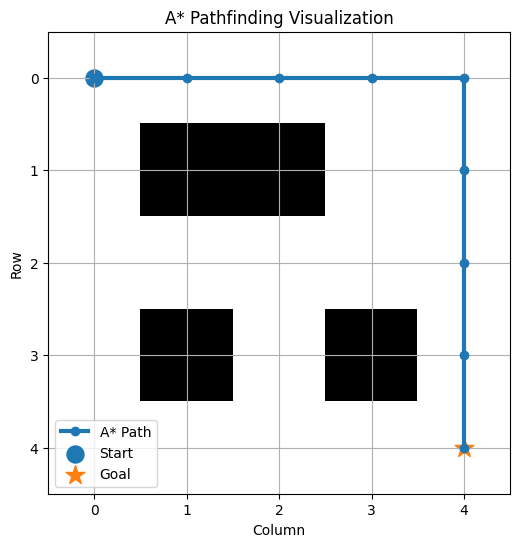

In [6]:
import heapq
import matplotlib.pyplot as plt

grid = [
    [0, 0, 0, 0, 0],
    [0, 1, 1, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 1, 0, 1, 0],
    [0, 0, 0, 0, 0]
]

start = (0, 0)
goal = (4, 4)


def heuristic(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


def astar(grid, start, goal):

    rows = len(grid)
    cols = len(grid[0])

    open_list = []
    heapq.heappush(open_list, (0, start))

    came_from = {}
    g_score = {start: 0}

    directions = [
        (-1, 0),
        (1, 0),
        (0, -1),
        (0, 1)
    ]

    while open_list:

        current_f, current = heapq.heappop(open_list)

        if current == goal:

            path = []

            while current in came_from:
                path.append(current)
                current = came_from[current]

            path.append(start)
            path.reverse()

            return path

        r, c = current

        for dr, dc in directions:

            nr = r + dr
            nc = c + dc

            if (
                0 <= nr < rows
                and 0 <= nc < cols
                and grid[nr][nc] == 0
            ):

                neighbor = (nr, nc)

                tentative_g = g_score[current] + 1

                if tentative_g < g_score.get(
                    neighbor, float("inf")
                ):

                    came_from[neighbor] = current
                    g_score[neighbor] = tentative_g

                    f = tentative_g + heuristic(
                        neighbor, goal
                    )

                    heapq.heappush(
                        open_list,
                        (f, neighbor)
                    )

    return None


# Find path
path = astar(grid, start, goal)

print("Path:")
print(path)


# -----------------------------
# DATA VISUALIZATION
# -----------------------------

plt.figure(figsize=(6, 6))

# Show grid
plt.imshow(grid, cmap="gray_r")

# Plot path
if path:
    x = [p[1] for p in path]
    y = [p[0] for p in path]

    plt.plot(
        x,
        y,
        marker="o",
        linewidth=3,
        label="A* Path"
    )

# Start point
plt.scatter(
    start[1],
    start[0],
    marker="o",
    s=150,
    label="Start"
)

# Goal point
plt.scatter(
    goal[1],
    goal[0],
    marker="*",
    s=200,
    label="Goal"
)

# Grid lines
plt.xticks(range(len(grid[0])))
plt.yticks(range(len(grid)))

plt.grid(True)

plt.title("A* Pathfinding Visualization")
plt.xlabel("Column")
plt.ylabel("Row")

plt.legend()

plt.show()

write a code to implement 8 puzzle problem using A* search with visualization


       8-PUZZLE USING A* SEARCH

Initial State:
1 2 3
4 0 6
7 5 8

Goal State:
1 2 3
4 5 6
7 8 0

Solving...

Solution Found!
-----------------------------------
Number of Moves : 2
States Explored : 3

Solution Path:
-----------------------------------
Step 0
1 2 3
4 0 6
7 5 8

Step 1
1 2 3
4 5 6
7 0 8

Step 2
1 2 3
4 5 6
7 8 0



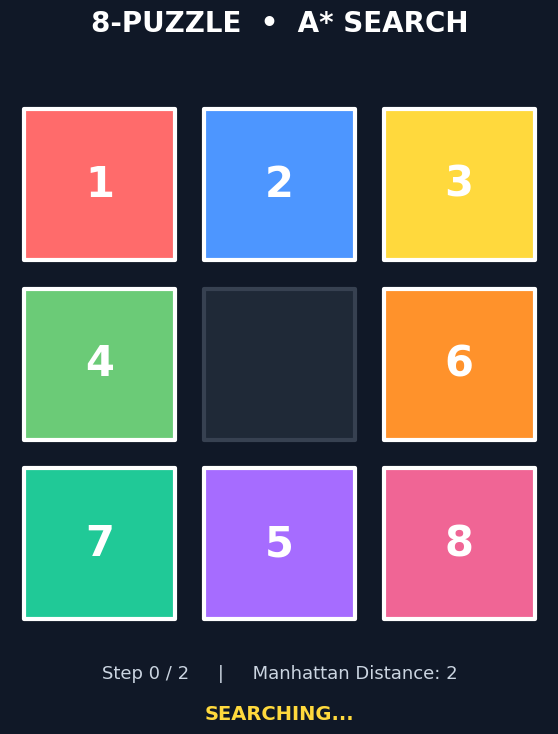

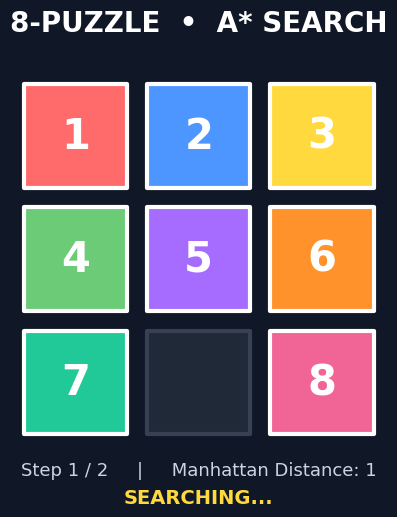

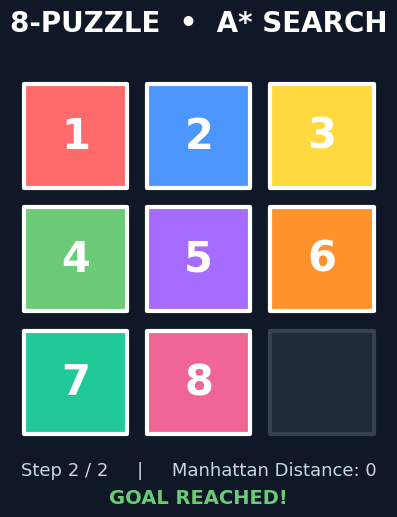

In [13]:
import heapq
import matplotlib.pyplot as plt
import time

# =========================================================
# 8-PUZZLE USING A* SEARCH WITH COLORFUL VISUALIZATION
# ========================================================= 

# 0 represents the blank space

START = (
    1, 2, 3,
    4, 0, 6,
    7, 5, 8
)

GOAL = (
    1, 2, 3,
    4, 5, 6,
    7, 8, 0
)


# =========================================================
# MANHATTAN DISTANCE
# =========================================================

def heuristic(state):

    distance = 0

    for i in range(9):

        tile = state[i]

        if tile == 0:
            continue

        current_row = i // 3
        current_col = i % 3

        goal_index = GOAL.index(tile)

        goal_row = goal_index // 3
        goal_col = goal_index % 3

        distance += abs(current_row - goal_row)
        distance += abs(current_col - goal_col)

    return distance


# =========================================================
# GENERATE NEIGHBOR STATES
# =========================================================

def get_neighbors(state):

    neighbors = []

    blank = state.index(0)
 
    row = blank // 3
    col = blank % 3

    moves = [
        (-1, 0),     # Up
        (1, 0),      # Down
        (0, -1),     # Left
        (0, 1)       # Right
    ]

    for dr, dc in moves:

        new_row = row + dr
        new_col = col + dc

        if 0 <= new_row < 3 and 0 <= new_col < 3:

            new_blank = new_row * 3 + new_col

            new_state = list(state)

            # Swap blank and tile
            new_state[blank], new_state[new_blank] = \
                new_state[new_blank], new_state[blank]

            neighbors.append(tuple(new_state))

    return neighbors


# =========================================================
# A* SEARCH
# =========================================================

def a_star(start, goal):

    # Priority queue
    # (f, g, state)

    open_list = []

    g_cost = {
        start: 0
    }

    parent = {}

    h = heuristic(start)

    heapq.heappush(
        open_list,
        (h, 0, start)
    )

    visited = set()

    while open_list:

        f, g, current = heapq.heappop(open_list)

        if current in visited:
            continue

        visited.add(current)

        # Goal reached
        if current == goal:

            path = []

            while current in parent:

                path.append(current)
                current = parent[current]

            path.append(start)

            path.reverse()

            return path, len(visited)

        # Generate next states
        for neighbor in get_neighbors(current):

            new_g = g + 1

            if neighbor in visited:
                continue

            if neighbor not in g_cost or new_g < g_cost[neighbor]:

                g_cost[neighbor] = new_g

                h = heuristic(neighbor)

                f = new_g + h

                parent[neighbor] = current

                heapq.heappush(
                    open_list,
                    (f, new_g, neighbor)
                )

    return None, len(visited)


# =========================================================
# COLORFUL PUZZLE VISUALIZATION
# =========================================================

def draw_puzzle(state, step, total_steps):

    plt.clf()

    fig = plt.gcf()

    fig.patch.set_facecolor("#101827")

    ax = plt.gca()

    ax.set_facecolor("#101827")

    ax.set_xlim(0, 3)
    ax.set_ylim(0, 3)

    ax.set_aspect("equal")

    ax.axis("off")

    # -----------------------------------------------------
    # Tile Colors
    # -----------------------------------------------------

    tile_colors = {
        1: "#FF6B6B",
        2: "#4D96FF",
        3: "#FFD93D",
        4: "#6BCB77",
        5: "#A66CFF",
        6: "#FF922B",
        7: "#20C997",
        8: "#F06595"
    }

    # -----------------------------------------------------
    # Draw Tiles
    # -----------------------------------------------------

    for i in range(9):

        tile = state[i]

        row = i // 3
        col = i % 3

        x = col
        y = 2 - row

        # Blank tile
        if tile == 0:

            rectangle = plt.Rectangle(
                (x + 0.08, y + 0.08),
                0.84,
                0.84,
                facecolor="#1F2937",
                edgecolor="#374151",
                linewidth=3,
                joinstyle="round"
            )

            ax.add_patch(rectangle)

            continue

        # Colored tile
        rectangle = plt.Rectangle(
            (x + 0.08, y + 0.08),
            0.84,
            0.84,
            facecolor=tile_colors[tile],
            edgecolor="white",
            linewidth=3,
            joinstyle="round"
        )

        ax.add_patch(rectangle)

        # Tile number
        ax.text(
            x + 0.5,
            y + 0.5,
            str(tile),
            fontsize=30,
            fontweight="bold",
            color="white",
            ha="center",
            va="center"
        )

    # -----------------------------------------------------
    # Title
    # -----------------------------------------------------

    ax.text(
        1.5,
        3.35,
        "8-PUZZLE  •  A* SEARCH",
        fontsize=20,
        fontweight="bold",
        color="white",
        ha="center"
    )

    # -----------------------------------------------------
    # Step Information
    # -----------------------------------------------------

    h = heuristic(state)

    if step == total_steps:

        status = "GOAL REACHED!"

    else:

        status = "SEARCHING..."

    ax.text(
        1.5,
        -0.25,
        f"Step {step} / {total_steps}     |     "
        f"Manhattan Distance: {h}",
        fontsize=13,
        color="#CBD5E1",
        ha="center"
    )

    ax.text(
        1.5,
        -0.48,
        status,
        fontsize=14,
        fontweight="bold",
        color="#6BCB77" if step == total_steps else "#FFD93D",
        ha="center"
    )

    plt.draw()

    plt.pause(1)


# =========================================================
# PRINT PUZZLE
# =========================================================

def print_state(state):

    for i in range(0, 9, 3):

        print(
            state[i],
            state[i + 1],
            state[i + 2]
        )

    print()


# =========================================================
# MAIN PROGRAM
# =========================================================

print("=" * 45)
print("       8-PUZZLE USING A* SEARCH")
print("=" * 45)

print("\nInitial State:")
print_state(START)

print("Goal State:")
print_state(GOAL)

print("Solving...\n")

# Run A*
path, explored = a_star(START, GOAL)


# =========================================================
# DISPLAY RESULT
# =========================================================

if path is None:

    print("No solution found.")

else:

    print("Solution Found!")
    print("-" * 35)

    print("Number of Moves :", len(path) - 1)
    print("States Explored :", explored)

    print("\nSolution Path:")
    print("-" * 35)

    for i, state in enumerate(path):

        print(f"Step {i}")
        print_state(state)


    # =====================================================
    # VISUALIZATION
    # =====================================================

    plt.ion()

    fig = plt.figure(
        figsize=(7, 7)
    )

    for step, state in enumerate(path):

        draw_puzzle(
            state,
            step,
            len(path) - 1
        )

    plt.ioff()

    plt.show()